In [43]:
!pip install sktime
!pip install pyarrow

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from sktime.transformations.panel.rocket import MiniRocketMultivariate

In [48]:
df = pd.read_csv("patient_vitals_clean.csv")

print(df.shape)

df.head()

(200020, 14)


,patient_id,heart_rate,respiratory_rate,timestamp,body_temperature,oxygen_saturation,systolic_blood_pressure,diastolic_blood_pressure,age,gender,weight_kg,height_m,hrv,risk_category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,High Risk


In [49]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

In [50]:
features = [
    "heart_rate",
    "respiratory_rate",
    "body_temperature",
    "oxygen_saturation",
    "systolic_blood_pressure",
    "diastolic_blood_pressure",
    "hrv"
]

stream = df[features].copy()

stream.head()

,heart_rate,respiratory_rate,body_temperature,oxygen_saturation,systolic_blood_pressure,diastolic_blood_pressure,hrv
0,69,14,37.012931,99.523058,133,78,0.096521
1,83,13,37.019873,95.362426,125,86,0.068300
2,81,13,36.665477,98.120530,124,89,0.097381
3,76,16,36.463631,99.340786,131,89,0.061232
4,87,17,37.058905,95.357470,120,84,0.129698


In [51]:
scaler = StandardScaler()

stream_scaled = scaler.fit_transform(stream)

stream_scaled = stream_scaled.astype(np.float32)

print(stream_scaled.shape)

(200020, 7)


In [52]:
def sliding_window_generator(data, window_size=30):

    for i in range(len(data) - window_size):

        yield data[i:i+window_size]

In [53]:
generator = sliding_window_generator(
    stream_scaled,
    window_size=30
)

first_window = next(generator)

print(first_window.shape)

(30, 7)


In [54]:
WINDOW_SIZE = 30
TRAIN_WINDOWS = 5000

generator = sliding_window_generator(
    stream_scaled,
    WINDOW_SIZE
)

windows = []

for _ in range(TRAIN_WINDOWS):

    windows.append(next(generator))

windows = np.array(windows, dtype=np.float32)

print(windows.shape)

(5000, 30, 7)


In [55]:
windows = np.transpose(
    windows,
    (0, 2, 1)
)

print(windows.shape)

(5000, 7, 30)


In [56]:
rocket = MiniRocketMultivariate(random_state=42)

rocket.fit(windows)

print("MiniROCKET trained successfully!")

MiniROCKET trained successfully!


In [57]:
rocket_features = rocket.transform(windows)

print(rocket_features.shape)

(5000, 9996)


In [58]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

iso.fit(rocket_features)

print("Isolation Forest trained!")

Isolation Forest trained!


In [59]:
predictions = iso.predict(rocket_features)

In [60]:
print("Normal:", np.sum(predictions == 1))
print("Anomalies:", np.sum(predictions == -1))

Normal: 4750
Anomalies: 250


In [61]:
scores = iso.decision_function(rocket_features)

In [62]:
from sklearn.preprocessing import MinMaxScaler

score_scaler = MinMaxScaler()

anomaly_score = score_scaler.fit_transform(
    (-scores).reshape(-1,1)
).flatten()

anomaly_score *= 100

In [63]:
results = pd.DataFrame({

    "Window": np.arange(len(anomaly_score)),

    "IsolationPrediction": predictions,

    "AnomalyScore": anomaly_score

})

results.head()

,Window,IsolationPrediction,AnomalyScore
0,0,1,42.583542
1,1,1,37.789110
2,2,1,37.936559
3,3,1,25.963654
4,4,1,19.280937


In [64]:
ALERT_THRESHOLD = 70

results["Alert"] = (
    results["AnomalyScore"] > ALERT_THRESHOLD
)

results.head()

,Window,IsolationPrediction,AnomalyScore,Alert
0,0,1,42.583542,False
1,1,1,37.789110,False
2,2,1,37.936559,False
3,3,1,25.963654,False
4,4,1,19.280937,False


In [65]:
print("Total Alerts:", results["Alert"].sum())

Total Alerts: 97


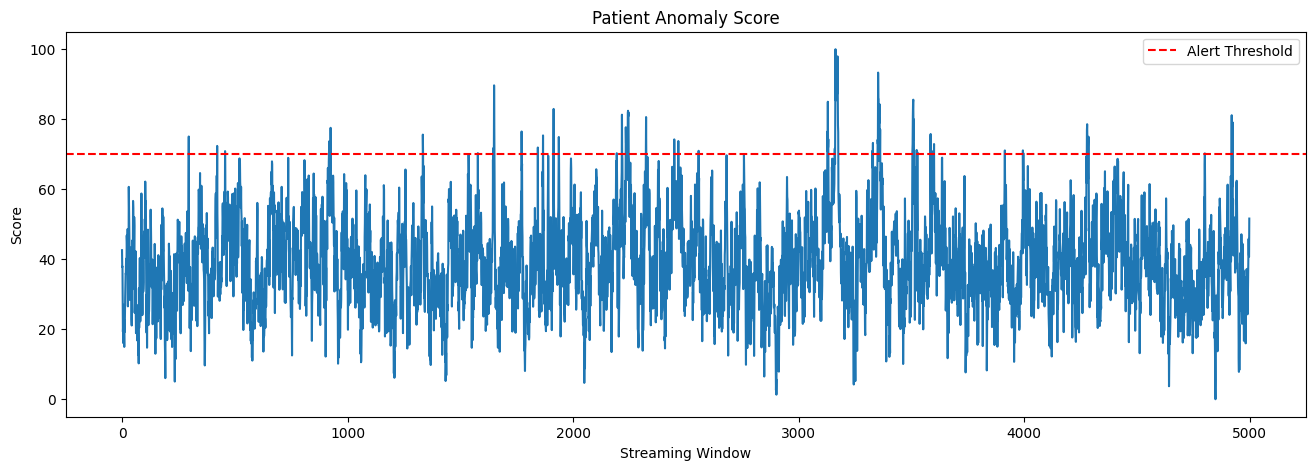

In [66]:
plt.figure(figsize=(16,5))

plt.plot(results["AnomalyScore"])

plt.axhline(
    ALERT_THRESHOLD,
    color="red",
    linestyle="--",
    label="Alert Threshold"
)

plt.title("Patient Anomaly Score")

plt.xlabel("Streaming Window")

plt.ylabel("Score")

plt.legend()

plt.show()

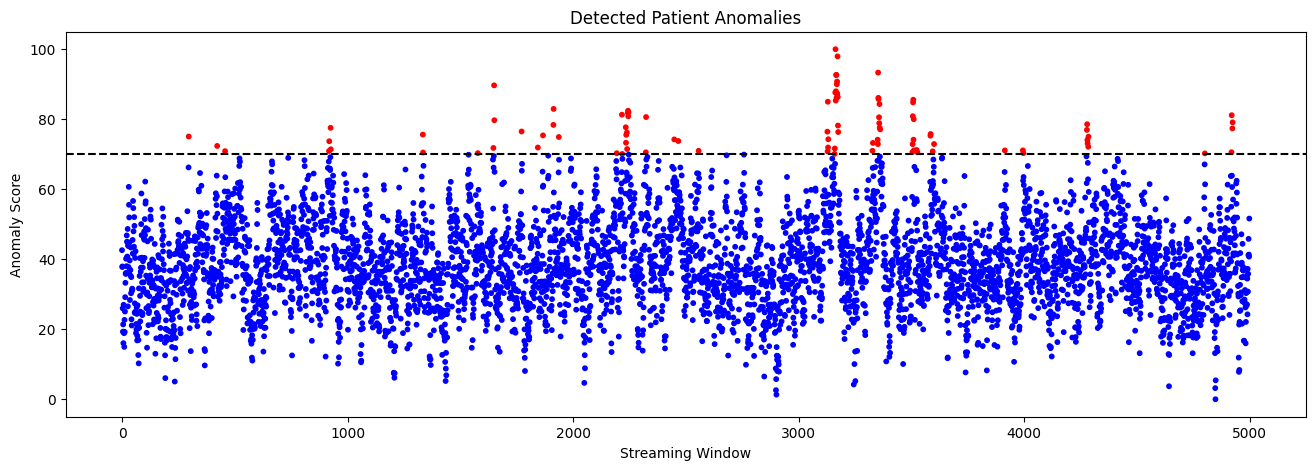

In [67]:
plt.figure(figsize=(16,5))

colors = np.where(
    results["Alert"],
    "red",
    "blue"
)

plt.scatter(
    results["Window"],
    results["AnomalyScore"],
    c=colors,
    s=10
)

plt.axhline(
    ALERT_THRESHOLD,
    color="black",
    linestyle="--"
)

plt.title("Detected Patient Anomalies")

plt.xlabel("Streaming Window")

plt.ylabel("Anomaly Score")

plt.show()

# 🩺 Machine Learning: Time-Series Anomaly Detection

## Overview

The Machine Learning module continuously monitors patient vital signs and detects abnormal physiological behavior in real time. Unlike traditional supervised classification models, this implementation follows an **unsupervised anomaly detection** approach that learns normal physiological patterns and identifies significant deviations that may indicate patient deterioration.

### Pipeline

```
Patient Vital Signs
        │
        ▼
Data Cleaning
        │
        ▼
Feature Selection
        │
        ▼
Standardization
        │
        ▼
Sliding Window Generation
        │
        ▼
MiniROCKET
        │
        ▼
Isolation Forest
        │
        ▼
Anomaly Score
        │
        ▼
Alert Generation
```

# 📊 Step 1 — Data Preparation

The patient vital signs dataset is loaded and sorted chronologically according to the timestamp.

Only **dynamic physiological variables** are retained:

- ❤️ Heart Rate
- 🫁 Respiratory Rate
- 🌡️ Body Temperature
- 🩸 Oxygen Saturation
- 💉 Systolic Blood Pressure
- 💉 Diastolic Blood Pressure
- 📈 Heart Rate Variability (HRV)

Static attributes such as **Age, Gender, Height, Weight,** and **Patient ID** are excluded because they do not represent short-term physiological changes.

# ⚙️ Step 2 — Data Normalization

The selected physiological signals are standardized using **StandardScaler**.

### Purpose

- Normalize different measurement scales
- Improve model stability
- Prevent features with large numerical ranges from dominating the learning process

Finally, all values are converted to **float32** to reduce memory usage during processing.

# ⏳ Step 3 — Sliding Window Generation

Since MiniROCKET is a **time-series model**, the continuous stream of patient measurements is divided into overlapping windows.

### Window Configuration

- Window Size: **30 consecutive readings**
- Signals: **7 physiological variables**
- Training Windows: **5,000**

Instead of loading every possible window into memory, a **streaming generator** creates windows sequentially, reducing memory consumption and simulating real-time IoT healthcare monitoring.

# 🚀 Step 4 — MiniROCKET Feature Extraction

MiniROCKET (MINImally RandOm Convolutional KErnel Transform) extracts temporal patterns from multivariate physiological signals.

Unlike conventional machine learning algorithms that analyze individual observations, MiniROCKET analyzes **temporal behavior across multiple time steps**.

### Input

- 30 Time Steps
- 7 Vital Sign Channels

### Output

- **9,996 extracted temporal features**

These features summarize physiological trends and temporal relationships that are difficult to capture using raw measurements alone.

# 🌲 Step 5 — Isolation Forest

The extracted MiniROCKET features are used to train an **Isolation Forest** model.

Isolation Forest is an unsupervised anomaly detection algorithm that isolates unusual observations using randomly generated decision trees.

### Model Parameters

- Trees: **300**
- Contamination: **5%**
- Random State: **42**

The model classifies each window as:

- ✅ Normal (1)
- 🚨 Anomaly (-1)

# 📈 Step 6 — Anomaly Score

Instead of producing only a binary prediction, the model calculates a continuous **Anomaly Score**.

The Isolation Forest decision function is normalized using **MinMaxScaler**.

### Score Range

- **0 → Normal**
- **100 → Highly Abnormal**

Higher anomaly scores indicate a greater deviation from learned normal physiological behavior.

# 🚨 Step 7 — Alert Generation

An alert mechanism is implemented using a predefined threshold.

### Alert Threshold

**70**

If

```
Anomaly Score > 70
```

the monitoring system generates an alert indicating possible patient deterioration.

### Results

- Windows Analyzed: **5,000**
- Detected Alerts: **97**

# 📊 Step 8 — Visualization

Two visualizations are generated.

### 1️⃣ Patient Anomaly Score

Displays the anomaly score for each streaming window together with the alert threshold.

---

### 2️⃣ Detected Patient Anomalies

Highlights abnormal windows in **red** while normal observations remain **blue**, allowing clinicians to quickly identify unusual physiological behavior.

# ✅ Conclusion

The implemented Machine Learning pipeline combines **MiniROCKET** and **Isolation Forest** to perform real-time anomaly detection on multivariate physiological time-series data.

The system:

- Learns normal physiological behavior
- Detects abnormal temporal patterns
- Computes an anomaly score between **0–100**
- Generates alerts for potential patient deterioration

This architecture is suitable for continuous healthcare monitoring systems where labeled anomaly data is limited and real-time detection is required.